# TensorFlow BBBP Baseline

This notebook mirrors the BBBP baseline in TensorFlow/Keras using a character-level text representation of SMILES.

Task: binary classification on BBBP
Model: TextVectorization plus dense classifier

In [60]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
RANDOM_SEED = 42
tf.keras.utils.set_random_seed(RANDOM_SEED)

In [61]:
PROJECT_ROOT = Path.cwd().parent.resolve()
DATA_DIR = Path(os.environ.get("DATA_DIR"))
bbbp = pd.read_csv(DATA_DIR / "BBBP.csv")
display(bbbp.head())

,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO3)=O
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)[C@@H](N4C3=O)C(O)=O


In [62]:
X = bbbp["smiles"]
y = bbbp["p_np"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)

In [63]:
vectorizer = tf.keras.layers.TextVectorization(
    standardize=None,
    split="character",
    output_mode="multi_hot",
    max_tokens=128,
)
vectorizer.adapt(tf.data.Dataset.from_tensor_slices(X_train.to_numpy()).batch(64))


def make_dataset(features, labels, training: bool):
    ds = tf.data.Dataset.from_tensor_slices(
        (features.to_numpy(), labels.to_numpy().astype("float32"))
    )
    if training:
        ds = ds.shuffle(buffer_size=len(features), seed=RANDOM_SEED)
    return ds.batch(64).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(X_train, y_train, training=True)
valid_ds = make_dataset(X_valid, y_valid, training=False)
test_ds = make_dataset(X_test, y_test, training=False)

2026-06-28 12:29:57.347804: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [64]:
model = tf.keras.Sequential(
    [
        tf.keras.Input(shape=(1,), dtype=tf.string),
        vectorizer,
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

history = model.fit(train_ds, validation_data=valid_ds, epochs=15, verbose=0)
history_df = pd.DataFrame(history.history)
display(history_df.tail().round(4))

,accuracy,auc,loss,val_accuracy,val_auc,val_loss
10,0.8132,0.8625,0.3812,0.8176,0.8675,0.3775
11,0.8181,0.8619,0.3782,0.8111,0.8681,0.3772
12,0.8084,0.8607,0.3787,0.8111,0.8692,0.3749
13,0.8223,0.8665,0.3722,0.8241,0.8683,0.3736
14,0.8230,0.8703,0.3667,0.8274,0.8691,0.3724


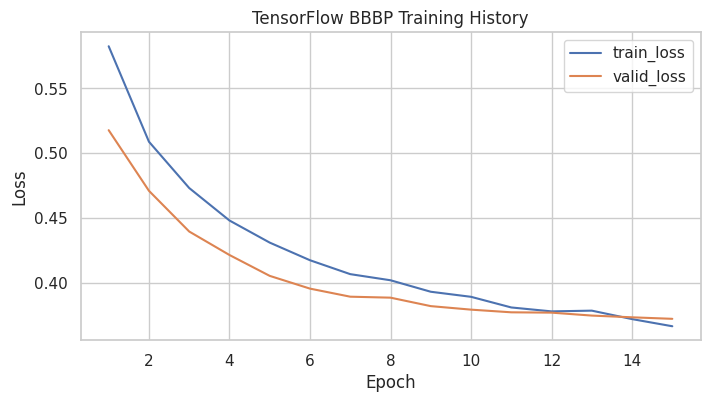

In [65]:
plt.figure(figsize=(8, 4))
plt.plot(history_df.index + 1, history_df["loss"], label="train_loss")
plt.plot(history_df.index + 1, history_df["val_loss"], label="valid_loss")
plt.title("TensorFlow BBBP Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [66]:
test_probs = model.predict(test_ds, verbose=0).ravel()
test_pred = (test_probs >= 0.5).astype(int)
test_metrics = pd.DataFrame(
    [
        {
            "accuracy": accuracy_score(y_test, test_pred),
            "f1": f1_score(y_test, test_pred),
            "roc_auc": roc_auc_score(y_test, test_probs),
        }
    ]
)
display(test_metrics.round(4))

,accuracy,f1,roc_auc
0,0.8312,0.8972,0.8799
